In [28]:
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1. Reloading Data

In [29]:
X_train = np.load("processed_data/X_train.npy")
X_test = np.load("processed_data/X_test.npy")
y_train = np.load("processed_data/y_train.npy")
y_test = np.load("processed_data/y_test.npy")

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1) 


# 2. Loading Model
- Saved entire bayes search object so we can do further analysis of the hyperparameter tuning

In [30]:
bayes_search = joblib.load("bayes_search_knn_clipped.pkl") # loading the best model (saved after hyperparameter tuning)

best_knn = bayes_search.best_estimator_ # defining the model parameters for our tuned model

# 3. Forming Predictions on Test Data

In [31]:
# fitting the label encoder on training labels
le = LabelEncoder()
le.fit(y_train)

# generating encoded predictions on test set
y_pred_enc = best_knn.predict(X_test)

# converting predictions back to labels (genres)
y_pred_labels = le.inverse_transform(y_pred_enc)

# 4. Aggregating Results - Get Predictions for Entire Song

In [32]:
song_ids = np.load("processed_data/song_ids_test.npy", allow_pickle=True) # loading the numpy array of all the song ids to identify all clips of one song

In [33]:
# creating a dataframe with the song ids, the true genre, and the predicted genre for each song clip
df_preds = pd.DataFrame({
    "song_id": song_ids,
    "true_genre": y_test,
    "pred_genre": y_pred_labels
})

# grouping by the song id and predicted genre to get all clips for one song togetherst
song_predictions = (
    df_preds.groupby("song_id")["pred_genre"]
    .agg(lambda x: x.value_counts().idxmax()) # counts the number of time each genre appears, picks the most frequent genre as the predicted label
)

# grouping by song id and true genre to get all clips for one song together, and the true genre label
song_true = (
    df_preds.groupby("song_id")["true_genre"]
    .first()
)

y_pred_labels = song_predictions.values
y_test = song_true.values

# 5. Analyze Hyperparameter Tuning Results
- Visualize how different values of k (number of neighbors) affect the F1 score
- This helps us understand the relationship between k and model performance

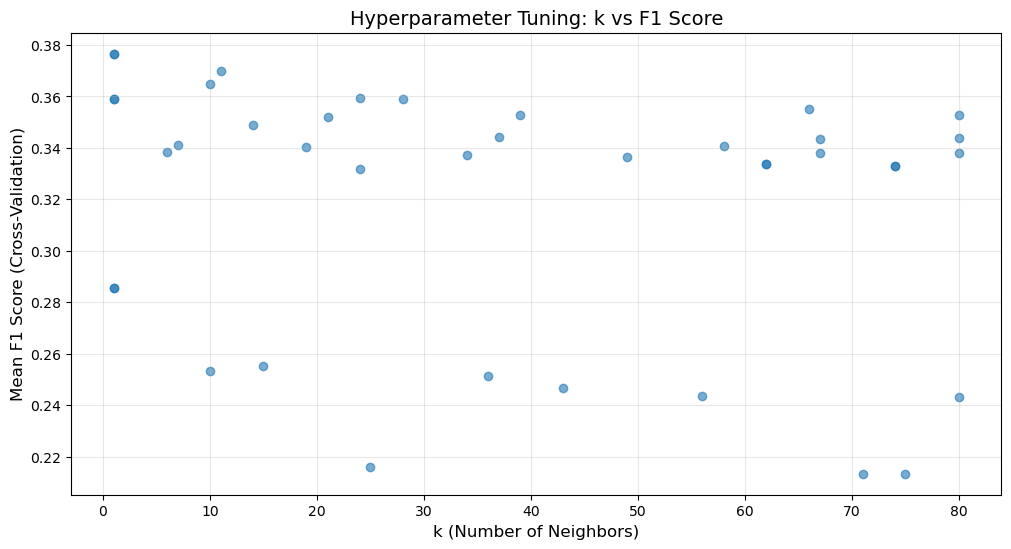

Best F1 Score: 0.3766
Best Parameters: OrderedDict([('metric', 'manhattan'), ('n_neighbors', 1), ('weights', 'distance')])


In [34]:
# Extract results from non-PCA hyperparameter search
cv_results_df = pd.DataFrame(bayes_search.cv_results_)

# Plot k vs F1 Score for non-PCA
plt.figure(figsize=(12, 6))
plt.scatter(cv_results_df['param_n_neighbors'], cv_results_df['mean_test_score'], alpha=0.6)
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Mean F1 Score (Cross-Validation)', fontsize=12)
plt.title('Hyperparameter Tuning: k vs F1 Score', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best F1 Score: {bayes_search.best_score_:.4f}")
print(f"Best Parameters: {bayes_search.best_params_}")

# 6. Model Evaluation and Comparison
- Use the best models from hyperparameter tuning to make predictions on test data
- Compare performance metrics (accuracy, precision, recall, F1-score)
- Generate classification reports to see performance for each genre

In [35]:
# Calculate metrics for model
print("="*70)
print("MODEL PERFORMANCE - CLIPPED SONGS")
print("="*70)
print(f"\nBest Hyperparameters: {bayes_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {bayes_search.best_score_:.4f}")
print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred_labels):.4f}")
print(f"Test Set F1 Score (Macro): {f1_score(y_test, y_pred_labels, average='macro'):.4f}")
print(f"Test Set Precision (Macro): {precision_score(y_test, y_pred_labels, average='macro'):.4f}")
print(f"Test Set Recall (Macro): {recall_score(y_test, y_pred_labels, average='macro'):.4f}")

print("\n" + "="*70)
print("Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred_labels))

MODEL PERFORMANCE - CLIPPED SONGS

Best Hyperparameters: OrderedDict([('metric', 'manhattan'), ('n_neighbors', 1), ('weights', 'distance')])
Best Cross-Validation F1 Score: 0.3766

Test Set Accuracy: 0.4600
Test Set F1 Score (Macro): 0.4300
Test Set Precision (Macro): 0.5401
Test Set Recall (Macro): 0.4600

Classification Report:
              precision    recall  f1-score   support

       blues       0.67      0.30      0.41        20
   classical       0.49      0.95      0.64        20
     country       0.67      0.10      0.17        20
       disco       0.50      0.20      0.29        20
      hiphop       0.67      0.60      0.63        20
        jazz       0.27      0.30      0.29        20
       metal       0.34      0.95      0.50        20
         pop       0.50      0.50      0.50        20
      reggae       0.86      0.30      0.44        20
        rock       0.44      0.40      0.42        20

    accuracy                           0.46       200
   macro avg      

# 7. Performance Analysis by Genre
- Identify which genres are classified correctly vs incorrectly
- Understand which genres are commonly confused with each other
- Analyze performance metrics for each individual genre

PER-GENRE PERFORMANCE METRICS
           precision  recall  f1-score  support
blues       0.666667    0.30  0.413793     20.0
classical   0.487179    0.95  0.644068     20.0
country     0.666667    0.10  0.173913     20.0
disco       0.500000    0.20  0.285714     20.0
hiphop      0.666667    0.60  0.631579     20.0
jazz        0.272727    0.30  0.285714     20.0
metal       0.339286    0.95  0.500000     20.0
pop         0.500000    0.50  0.500000     20.0
reggae      0.857143    0.30  0.444444     20.0
rock        0.444444    0.40  0.421053     20.0


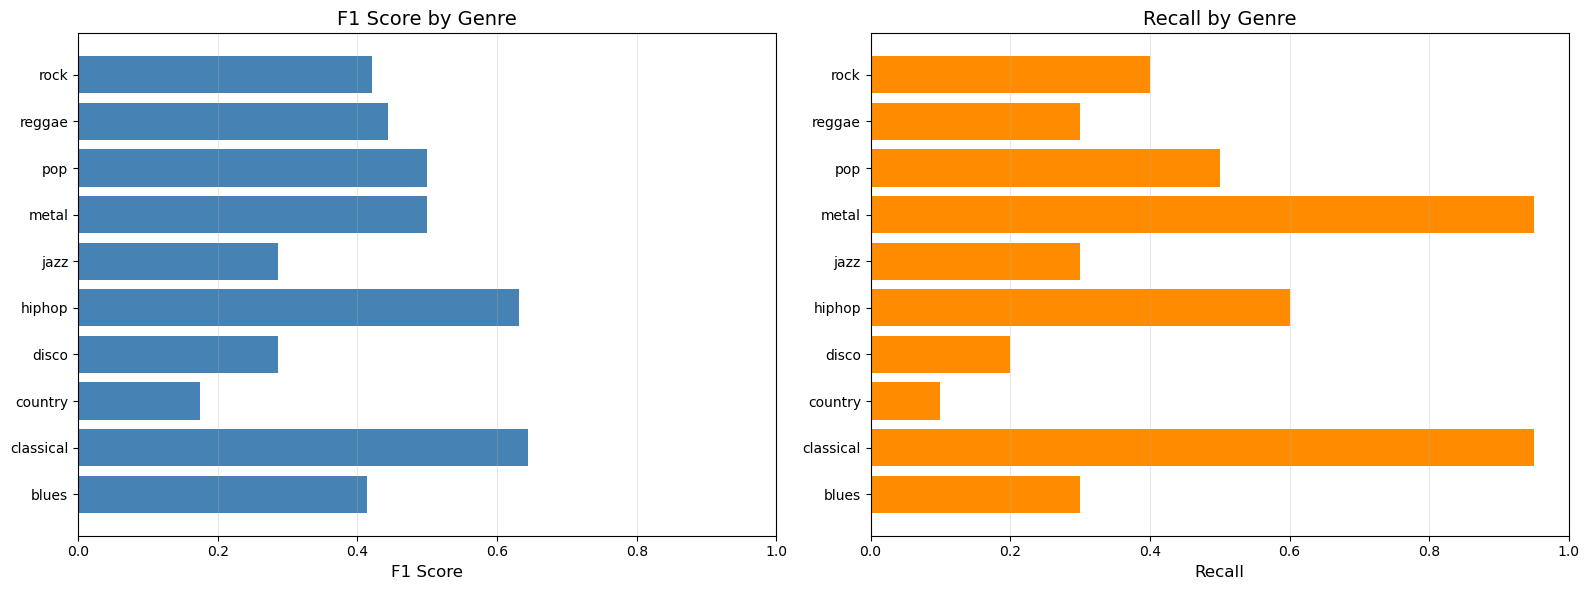

In [36]:
# making a list of all the genres
genres = sorted(np.unique(y_test))

# Get detailed performance metrics by genre
report = classification_report(y_test, y_pred_labels, output_dict=True)

# Convert to DataFrame for better visualization
df_report = pd.DataFrame(report).transpose()

# Display genre-level metrics
print("="*70)
print("PER-GENRE PERFORMANCE METRICS")
print("="*70)
print(df_report.head(len(genres)))

# Extract F1 and recall (per-genre accuracy)
f1_scores = [report[genre]['f1-score'] for genre in genres]
accuracy_by_genre = [report[genre]['recall'] for genre in genres]

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot F1 scores
ax1.barh(genres, f1_scores, color='steelblue')
ax1.set_xlabel('F1 Score', fontsize=12)
ax1.set_title('F1 Score by Genre', fontsize=14)
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Plot accuracy (recall) by genre
ax2.barh(genres, accuracy_by_genre, color='darkorange')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_title('Recall by Genre', fontsize=14)
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Finish Analysis - Does this look similar/different to full songs? 
- Can use the function below to run the analysis for specific genres that look good/bad performing

In [37]:
# defining function to compute the number of songs predicted across all genres for the positive genre

def plot_prediction_frequency(target_genre):

    rates = [] # will hold the rate of not target_genre for all songs that are the target_genre

    for g in genres: # looping through each genre
        subset = y_pred_labels[y_test == g] # separating to get only songs of the true_genre
        rate = np.mean(subset == target_genre) # calculates the proportion predicted as target_genre
        rates.append(rate) # appends to list

    sns.barplot(x=genres, y=rates) # creates barplot to display rates by genre

    plt.xticks(rotation=45)
    plt.ylabel(f"Proportion Predicted as {target_genre.capitalize()}")
    plt.xlabel("True Genre")
    plt.title(f"Frequency of {target_genre.capitalize()} Predictions by True Genre")

    plt.show()